# Pose-Graph SLAM Comparison to Dead Reckoning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional
import timeit
import slam_utils as utils

def benchmark(func, runs=10):
    t = timeit.timeit(func, number=runs)
    return t / runs

In this example, we consider a differential drive robot with odometry and loop-closure measurements. We will have the robot drive a square trajectory through the world, and then use pose-graph SLAM to estimate the trajectory driven by the robot.

The state of the differential drive robot consists of the two-dimensional pose (position and heading), $\textbf{x} = [x, y, \theta]^\top$.
The dynamics model is:
\begin{equation*}
\dot{x} = v\cos(\theta), \quad \dot{y} = v\sin(\theta), \quad \dot{\theta} = \omega,
\end{equation*}
where $v$ is the speed command and $\omega$ is the angular velocity command.

Below, we define the `Robot` class. This class defines the robot dynamics (computed using an exact discretization method) and includes a loop closure and odometry measurement model, both of which provide relative poses between two states (with noise).

In [2]:
class Robot:
    """
    Robot that measures odometry and can detect loop closures.
    """
    def __init__(
        self,
        odom_cov: np.ndarray,
        loop_closure_cov: np.ndarray,
    ):
        """
        Args:
            odom_cov: covariance matrix for odometry motion model noise
            loop_closure_cov: covariance matrix for loop closure measurement noise
        """
        self.odom_cov = odom_cov
        self.loop_closure_cov = loop_closure_cov
    
    def step(self, x: np.ndarray, u: np.ndarray, dt: float, add_noise: bool=True) -> np.ndarray:
        """
        Integrate differential drive model for dt seconds given the control input.

        Args:
            x: state vector, [px, py, th]
            u: control vector, [v, ω]
            dt: time step
            add_noise: whether to add control noise

        Returns:
            State after dt seconds.
        """
        px, py, th = x
        v, ω = u
        if abs(ω) < 1e-9:
            return np.array([px + v * dt * np.cos(th),
                             py + v * dt * np.sin(th),
                             th])

        # Compute turning radius
        r = v / ω

        # Compute change in angle over timestep
        dth = ω * dt

        # Compute center of rotation
        cx  = px - r * np.sin(th)
        cy  = py + r * np.cos(th)

        # Compute new angle and update position on circle
        th2 = th + dth
        px2  = cx + r * np.sin(th2)
        py2  = cy - r * np.cos(th2)
        return np.array([px2, py2, utils.wrap_angle(th2)])

    def add_noise(self, x: np.ndarray, cov: np.ndarray) -> np.ndarray:
        """
        Add noise to the input array given a covariance matrix.

        Args:
            x: array to add noise to, shape (n,)
            cov: covariance matrix for multivariate normal noise, shape (n,n)

        Returns:
            Array x with added noise.
        """
        return x + np.random.multivariate_normal(np.zeros(len(x)), cov)

    def odometry_measurement(self, x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
        """
        Given a current pose and next pose, compute a noisy odometry
        measurement of the relative pose.

        Args:
            x1: current pose
            x2: next pose

        Returns:
            Noisy measurement of relative pose.
        """
        rel_pose_true  = utils.se2_between(x1, x2)
        return self.add_noise(rel_pose_true, self.odom_cov)

    def loop_closure_measurement(self, x0: np.ndarray, xT: np.ndarray) -> np.ndarray:
        """
        Compute a noisy loop closure measurement of the relative pose between
        an initial and final pose.

        Args:
            x0: initial pose
            xT: final pose

        Returns:
            Noisy measurement of relative pose between x0 and xT.
        """
        lc_true = utils.se2_between(x0, xT)
        return self.add_noise(lc_true, self.loop_closure_cov)

def simulate(
    robot: Robot,
    world: utils.World,
    controls: np.ndarray,
    dt: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Simulate robot following open-loop control sequence while collecting 
    odometry, range-bearing, and loop-closure measurements.

    Args:
        robot: robot to simulate
        world: world to simulate
        controls: open-loop sequence of controls, [u, ω], shape (T, 2)
        dt: timestep

    Returns:
        Ground-truth robot trajectory, shape (T + 1, 3)
        Odometry measurements, shape (T, 3)
        Loop-closure measurement, shape (3,)
    """
    T = controls.shape[0]
    x = np.zeros((T + 1, 3))
    odom_meas = np.zeros((T, 3))
    lm_meas = []
    for t in range(T):
        # Simulate robot
        x[t + 1] = robot.step(x[t], controls[t, :], dt)

        # Odometry rel. measurements
        odom_meas[t] = robot.odometry_measurement(x[t], x[t + 1])

    # Loop closure measurement
    lc_meas = robot.loop_closure_measurement(x[0], x[-1])
    return x, odom_meas, lm_meas, lc_meas

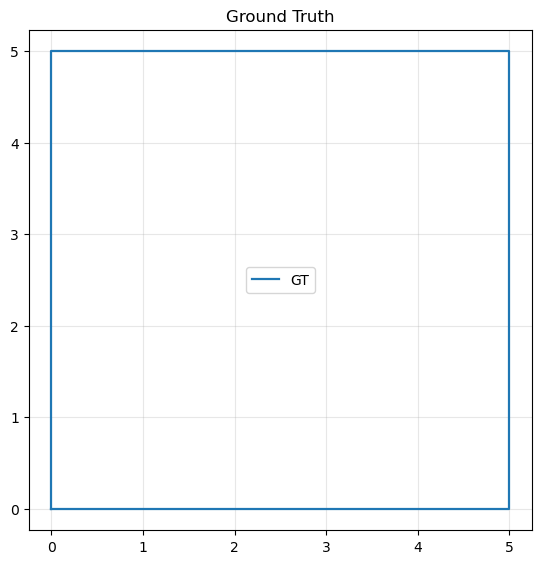

In [3]:
# Create simple world
world = utils.make_simple_world()

# Define robot and the various covariances for its measurements
odom_cov = np.diag([0.03**2, 0.03**2, (np.deg2rad(1.0))**2])
loop_closure_cov = 0.2 * odom_cov
robot = Robot(odom_cov=odom_cov, 
              loop_closure_cov=loop_closure_cov)

# Simulate a square trajectory and compute simulated measurements
dt = 0.5
controls = utils.square_loop_control_sequence(world, v=0.25, dt=dt)
np.random.seed(3)  # stable example
x_gt, odom_meas, lm_meas, lc_meas = simulate(robot, world, controls, dt)

# Plot the world's landmarks and ground truth robot trajectory
utils.plot_traj("Ground Truth", {"GT": x_gt})

### Odometry-Only Localization (Dead Reckoning)
In this first example, we have the simplest and least accurate approach that is based on only odometry measurements where the robot is using its own sensors to estimate its motion (e.g. using wheel encoders). Specifically, we use the `odom_meas` outputs from the robot's simulated trajectory computed above.

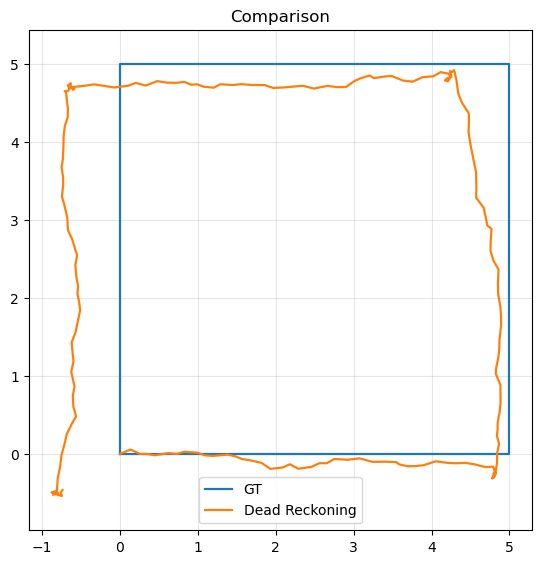

=== Error metric and execution time ===
Odometry only: 0.598 m, time: 1.57 ms


In [4]:
def dead_reckoning(odom_meas: np.ndarray) -> np.ndarray:
    T = odom_meas.shape[0]
    x = np.zeros((T+1, 3))
    for t, rel in enumerate(odom_meas):
        x[t+1] = utils.se2_compose(x[t], rel)
    return x

# Compute odometry based trajectory estimate and compare to ground-truth
x_odom = dead_reckoning(odom_meas)
time_odom = benchmark(lambda: dead_reckoning(odom_meas))
utils.plot_traj("Comparison", {"GT": x_gt, "Dead Reckoning": x_odom})
rmse_odom = utils.absolute_trajectory_rmse(x_gt, x_odom)
print("=== Error metric and execution time ===")
print(f"Odometry only: {rmse_odom:.3f} m, time: {1000*time_odom:.2f} ms")

### Smoothing-based Approach: Pose-graph SLAM
Unlike incremental approaches like the filter-based EKF SLAM, pose-graph SLAM is a smoothing approach called that performs a global optimization problem given all data.

In [5]:
def pose_graph_optimize(robot: Robot,
                        odom_meas: np.ndarray,
                        lc_meas: Optional[np.ndarray],
                        iters: int=10,
                        lm_lambda: float=1e-3) -> np.ndarray:
    """
    Run pose-graph optimization. Runs a weighted Gauss–Newton with LM damping.

    Args:
        robot: robot data
        odom_meas: odometry measurements along trajectory, shape (T, 3)
        lc_meas: loop closure measurement, shape (3,), or None to not use
                 loop closure
        iters: number of iterations of
        lm_lambda: LM damping parameter

    Returns:
        Optimized trajectory estimate, shape (T, 3)
    """
    T = odom_meas.shape[0]
    X = dead_reckoning(odom_meas)  # initializer
    use_loop_closure = lc_meas is not None

    # Weight matrices
    W_odom = np.linalg.inv(robot.odom_cov)
    W_lc = np.linalg.inv(robot.loop_closure_cov) if use_loop_closure else None

    def residual_and_jac(X):
        res_blocks, J_blocks, W_blocks = [], [], []
        eps = 1e-6

        def residual(x1, x2, odom_meas):
            odom_pred = utils.se2_between(x1, x2)
            return utils.se2_rel_residual(odom_pred, odom_meas)

        # Numerically compute Jacobians wrt X_t and X_{t+1}
        def residual_jacobians(x1, x2, z):
            """
            Computes numerical Jacobians of the residual r(x1, x2) with respect
            to x1 and x2.
            """
            A = np.zeros((3, 6)) # [A_1, A_2]
            for i in range(2):
                for k in range(3):
                    # Do a numerical estimate of derivative for i-th index
                    x1_copy = x1.copy()
                    x2_copy = x2.copy()
                    x_to_perturb = x1_copy if i == 0 else x2_copy
                    x_to_perturb[k] += eps
                    ra = residual(x1_copy, x2_copy, z)
                    x_to_perturb[k] -= 2 * eps
                    rb = residual(x1_copy, x2_copy, z)
                    A[:, 3 * i + k] = (ra - rb) / (2 * eps)
            return A
            
        # Odometry edges
        for t in range(T):
            # Compute predicted odometry and residual with measured value
            res_blocks.append(residual(X[t], X[t + 1], odom_meas[t]))
                        
            # Compute Jacobians and add to block
            Jb = np.zeros((3, 3 * (T + 1)))
            t_idx = 3 * t
            Jb[:, t_idx:t_idx + 6] = residual_jacobians(X[t], X[t + 1], odom_meas[t])
            J_blocks.append(Jb)
            W_blocks.append(W_odom)
            
        # Loop-closure edge
        if use_loop_closure:
            # Compute predicted odometry and residual with measured value
            r = residual(X[0], X[T], lc_meas)
            res_blocks.append(r)

            # Compute Jacobians and add to block
            Jb = np.zeros((3, 3 * (T + 1)))
            A = residual_jacobians(X[0], X[T], lc_meas)
            Jb[:, :3] = A[:, :3]
            Jb[:, 3 * T:] = A[:, 3:]
            J_blocks.append(Jb)
            W_blocks.append(W_lc)

        # Stack (block-diag weights)
        R = np.hstack(res_blocks)
        J = np.vstack(J_blocks)
        W = np.zeros((3 * len(W_blocks), 3 * len(W_blocks)))
        for i, Wi in enumerate(W_blocks):
            W[3*i:3*(i+1), 3*i:3*(i+1)] = Wi
        return R, J, W

    # Run optimization iterations
    for i in range(iters):
        R, J, W = residual_and_jac(X)
        
        # Fix the gauge by removing columns of X0
        mask = np.ones(J.shape[1], dtype=bool)
        mask[0:3] = False
        Jred = J[:, mask]
        
        # Weighted normal equations with LM damping
        H = Jred.T @ W @ Jred
        A = H + lm_lambda * np.eye(Jred.shape[1])
        b = -Jred.T @ W @ R

        # Solve for step dx
        dx = np.linalg.lstsq(A, b, rcond=None)[0]

        # Apply dx to update the solution (except the fixed first part)
        Xv = X.reshape(-1)
        Xv[3:] += dx
        X = Xv.reshape(-1, 3)
        X[:, 2] = np.array([utils.wrap_angle(a) for a in X[:, 2]])
    return X

Now run the Pose-graph SLAM with and without loop closure below. Note this may take a while to run. Given only the odometry measurements and no loop closure, the pose-graph solution should look like the dead recknoning estimate, but when adding the loop closure measurement it should drastically improve.

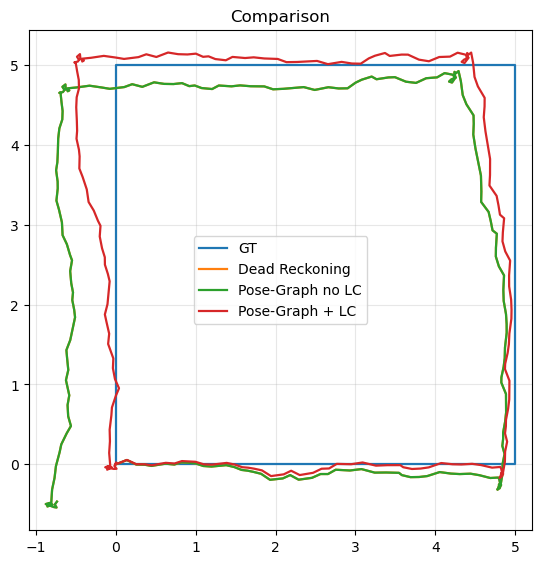

=== Error metric and execution time ===
Odometry only      : 0.598 m, time: 1.57 ms
Pose-graph (no LC) : 0.598 m, time: 0.00 ms
Pose-graph (+ LC)  : 0.345 m, time: 0.00 ms


In [6]:
# Run Pose-graph SLAM without loop closure
x_pg_no_lc = pose_graph_optimize(robot, odom_meas, lc_meas=None)
time_pg_no_lc = 0
# time_pg_no_lc = benchmark(lambda: pose_graph_optimize(robot, odom_meas, lc_meas=None))

# Run Pose-graph SLAM with loop closure
x_pg_lc = pose_graph_optimize(robot, odom_meas, lc_meas=lc_meas)
time_pg_lc = 0
# time_pg_lc = benchmark(lambda: pose_graph_optimize(robot, odom_meas, lc_meas=lc_meas))

# Compare results
utils.plot_traj("Comparison", {"GT": x_gt, 
                         "Dead Reckoning": x_odom, 
                         "Pose-Graph no LC": x_pg_no_lc,
                         "Pose-Graph + LC": x_pg_lc})
rmse_pg_no_lc = utils.absolute_trajectory_rmse(x_gt, x_pg_no_lc)
rmse_pg_lc = utils.absolute_trajectory_rmse(x_gt, x_pg_lc)
print("=== Error metric and execution time ===")
print(f"Odometry only      : {rmse_odom:.3f} m, time: {1000*time_odom:.2f} ms")
print(f"Pose-graph (no LC) : {rmse_pg_no_lc:.3f} m, time: {1000*time_pg_no_lc:.2f} ms")
print(f"Pose-graph (+ LC)  : {rmse_pg_lc:.3f} m, time: {1000*time_pg_lc:.2f} ms")